# Memory experiment replication

This notebook aims at replicating the results from the memory experiment already implemented in `stim`. It serves as an example on how to use the `tqec` Python library as well as a large functional test, testing most of the `tqec` library on its external results rather than on its internal implementation.

## Mandatory imports

In [1]:
import cirq
import matplotlib.pyplot as plt
import sinter
import stim
from stimcirq import cirq_circuit_to_stim_circuit

from tqec.templates.constructions.qubit import QubitSquareTemplate
from tqec.templates.scale import Dimension, LinearFunction
from tqec.circuit.operations import (
    make_observable,
    make_shift_coords,
    transform_to_stimcirq_compatible,
)
from tqec.enums import PlaquetteOrientation
from tqec.circuit.circuit import generate_circuit
from tqec.noise_models import (
    AfterCliffordDepolarizingNoise,
    AfterResetFlipNoise,
    BeforeMeasurementFlipNoise,
)
from tqec.plaquette.plaquette import Plaquette
from tqec.plaquette.library import (
    ZSquareInitialisationPlaquette,
    ZRoundedInitialisationPlaquette,
    XXMemoryPlaquette,
    XXXXMemoryPlaquette,
    ZZMemoryPlaquette,
    ZZZZMemoryPlaquette,
    MeasurementSquarePlaquette,
    MeasurementRoundedPlaquette,
)

## Normalisation and noisyness

Once the quantum error correction circuit implemented, we still need to apply two passes to obtain a circuit ready to be translated by the `stimcirq`.

The first pass normalises the `cirq.Circuit` produced. This pass was performing several modifications before, but is now simply removing potential empty `cirq.Moment` instances from the `cirq.Circuit` instance.

The second pass applies the noise model(s) we want to consider in the `stim` simulation.

In [2]:
def normalise_circuit(circuit: cirq.Circuit) -> cirq.Circuit:
    ordered_transformers = [
        cirq.drop_empty_moments,
    ]
    for transformer in ordered_transformers:
        circuit = transformer(circuit)
    return circuit


def to_noisy_circuit(circuit: cirq.Circuit, noise_level: float) -> cirq.Circuit:
    noise_models = [
        AfterCliffordDepolarizingNoise(noise_level),
        AfterResetFlipNoise(noise_level),
        BeforeMeasurementFlipNoise(noise_level),
    ]
    for nm in noise_models:
        circuit = circuit.with_noise(nm)
    return circuit

## Building the Circuit instance

The main goal of the `tqec` library is to construct the `cirq.Circuit` instance representing the QEC experiment we are interest about. In this notebook, we want to perform a simple logical qubit memory experiment.

The different pre-defined Plaquette instances `XXPlaquetteList`, ... implement by default the memory experiment, so we can use them without worrying about the quantum circuits actually executed.

In [3]:
from tqec.templates.display import display_template


def generate_cirq_circuit_tqec(k: int, repetitions: int) -> cirq.Circuit:
    # 1. Define the template.
    # Here, the template is directly constructed to the requested dimensions, so we do not need to
    # re-scale it using the Template.to_scale method.
    template = QubitSquareTemplate(Dimension(k, LinearFunction(2)))

    print("Template:")
    display_template(template)

    # 2. Define the different plaquettes that will be used on the template defined above.
    # As noted in the text description above this function, the plaquette instances in the list below
    # implement by default the memory experiment we want to perform. That is the reason why there is no
    # tedious quantum circuit definition here.
    # The following time schedules are used accross plaquettes:
    # - Initial reset index is 1
    # - (H gate for X-stabilizers is 2)
    # - CNOTs indices are 3, 4, 5, 6
    # - (H gate for X-stabilizers is 7)
    # - Measurement index is 8
    plaquettes: list[list[Plaquette]] = [
        [
            ZRoundedInitialisationPlaquette(PlaquetteOrientation.UP),
            XXMemoryPlaquette(
                PlaquetteOrientation.UP,
                [1, 4, 5, 6, 7],
                include_detector=False,
                is_first_round=True,
            ),
            XXMemoryPlaquette(PlaquetteOrientation.UP, [1, 2, 5, 6, 7, 8]),
            MeasurementRoundedPlaquette(
                PlaquetteOrientation.UP, include_detector=False
            ),
        ],
        [
            ZRoundedInitialisationPlaquette(PlaquetteOrientation.LEFT),
            ZZMemoryPlaquette(
                PlaquetteOrientation.LEFT, [4, 5, 7], is_first_round=True
            ),
            ZZMemoryPlaquette(PlaquetteOrientation.LEFT, [1, 5, 6, 8]),
            MeasurementRoundedPlaquette(PlaquetteOrientation.LEFT),
        ],
        [
            ZSquareInitialisationPlaquette(),
            XXXXMemoryPlaquette(
                [1, 2, 3, 4, 5, 6, 7], include_detector=False, is_first_round=True
            ),
            XXXXMemoryPlaquette([1, 2, 3, 4, 5, 6, 7, 8]),
            MeasurementSquarePlaquette(include_detector=False),
        ],
        [
            ZSquareInitialisationPlaquette(),
            ZZZZMemoryPlaquette([2, 3, 4, 5, 7], is_first_round=True),
            ZZZZMemoryPlaquette([1, 3, 4, 5, 6, 8]),
            MeasurementSquarePlaquette(),
        ],
        [
            ZRoundedInitialisationPlaquette(PlaquetteOrientation.RIGHT),
            ZZMemoryPlaquette(
                PlaquetteOrientation.RIGHT, [2, 3, 7], is_first_round=True
            ),
            ZZMemoryPlaquette(PlaquetteOrientation.RIGHT, [1, 3, 4, 8]),
            MeasurementRoundedPlaquette(PlaquetteOrientation.RIGHT),
        ],
        [
            ZRoundedInitialisationPlaquette(PlaquetteOrientation.DOWN),
            XXMemoryPlaquette(
                PlaquetteOrientation.DOWN,
                [1, 2, 3, 6, 7],
                include_detector=False,
                is_first_round=True,
            ),
            XXMemoryPlaquette(PlaquetteOrientation.DOWN, [1, 2, 3, 4, 7, 8]),
            MeasurementRoundedPlaquette(
                PlaquetteOrientation.DOWN, include_detector=False
            ),
        ],
    ]

    # 3. Define the layer modifiers.
    # In the memory experiment, we want to repeat the second layer `repetitions` times in order to
    # let the experiment run for an extended period of time.
    # This is done by encapsulating the circuit generated for the second layer into a
    # cirq.CircuitOperation that natively supports repeting an operation efficiently, and that is
    # natively recognized by the `tqec` library.
    def make_repeated_layer(circuit: cirq.Circuit) -> cirq.Circuit:
        circuit_to_repeat = circuit + cirq.Circuit(
            cirq.Moment(make_shift_coords(0, 0, 1))
        )
        repeated_circuit_operation = cirq.CircuitOperation(
            circuit_to_repeat.freeze()
        ).repeat(repetitions)
        return cirq.Circuit([repeated_circuit_operation])

    layer_modificators = {2: make_repeated_layer}

    # 4. Actually create the cirq.Circuit instance by concatenating the circuits generated
    # for each layer and potentially modified by the modifiers defined above.
    circuit = cirq.Circuit()
    for layer_index in range(4):
        layer_circuit = generate_circuit(
            template,
            [plaquette_list[layer_index] for plaquette_list in plaquettes],
        )
        layer_circuit = normalise_circuit(layer_circuit)
        circuit += layer_modificators.get(layer_index, lambda circ: circ)(layer_circuit)
        circuit += cirq.Moment(make_shift_coords(0, 0, 1))

    # 5. Define the observable.
    # The observable is defined and added to the cirq.Circuit instance just here.
    increments = template.get_increments()
    origin = cirq.GridQubit(increments.y * k + 1, 1)
    circuit.append(
        cirq.Moment(
            make_observable(
                origin,
                [
                    (cirq.GridQubit(0, i * increments.x), -1)
                    for i in range(0, template.shape.x - 1)
                ],
            )
        )
    )

    # 6. Due to limitations in the API provided by Stim, the DetectorGate and ObservableGate instances
    # in the circuit only contain local measurement records, an internal representation that is not
    # understood by Stim. The fill_in_global_record_indices function replaces these local measurement
    # records by global ones that are understood by Stim.
    # return circuit
    return transform_to_stimcirq_compatible(circuit)

## Build the circuit

In [4]:
from tqec.circuit.operations.measurement_map import flatten
from tqec.circuit.clifford.tableau import TableauWithCollapsingOperations


circuit = flatten(generate_cirq_circuit_tqec(1, 1))
tableau = TableauWithCollapsingOperations.from_circuit(circuit)

imap = tableau.get_interaction_map()

Template:
  .  .  1  .
  2  3  4  .
  .  4  3  5
  .  6  .  .


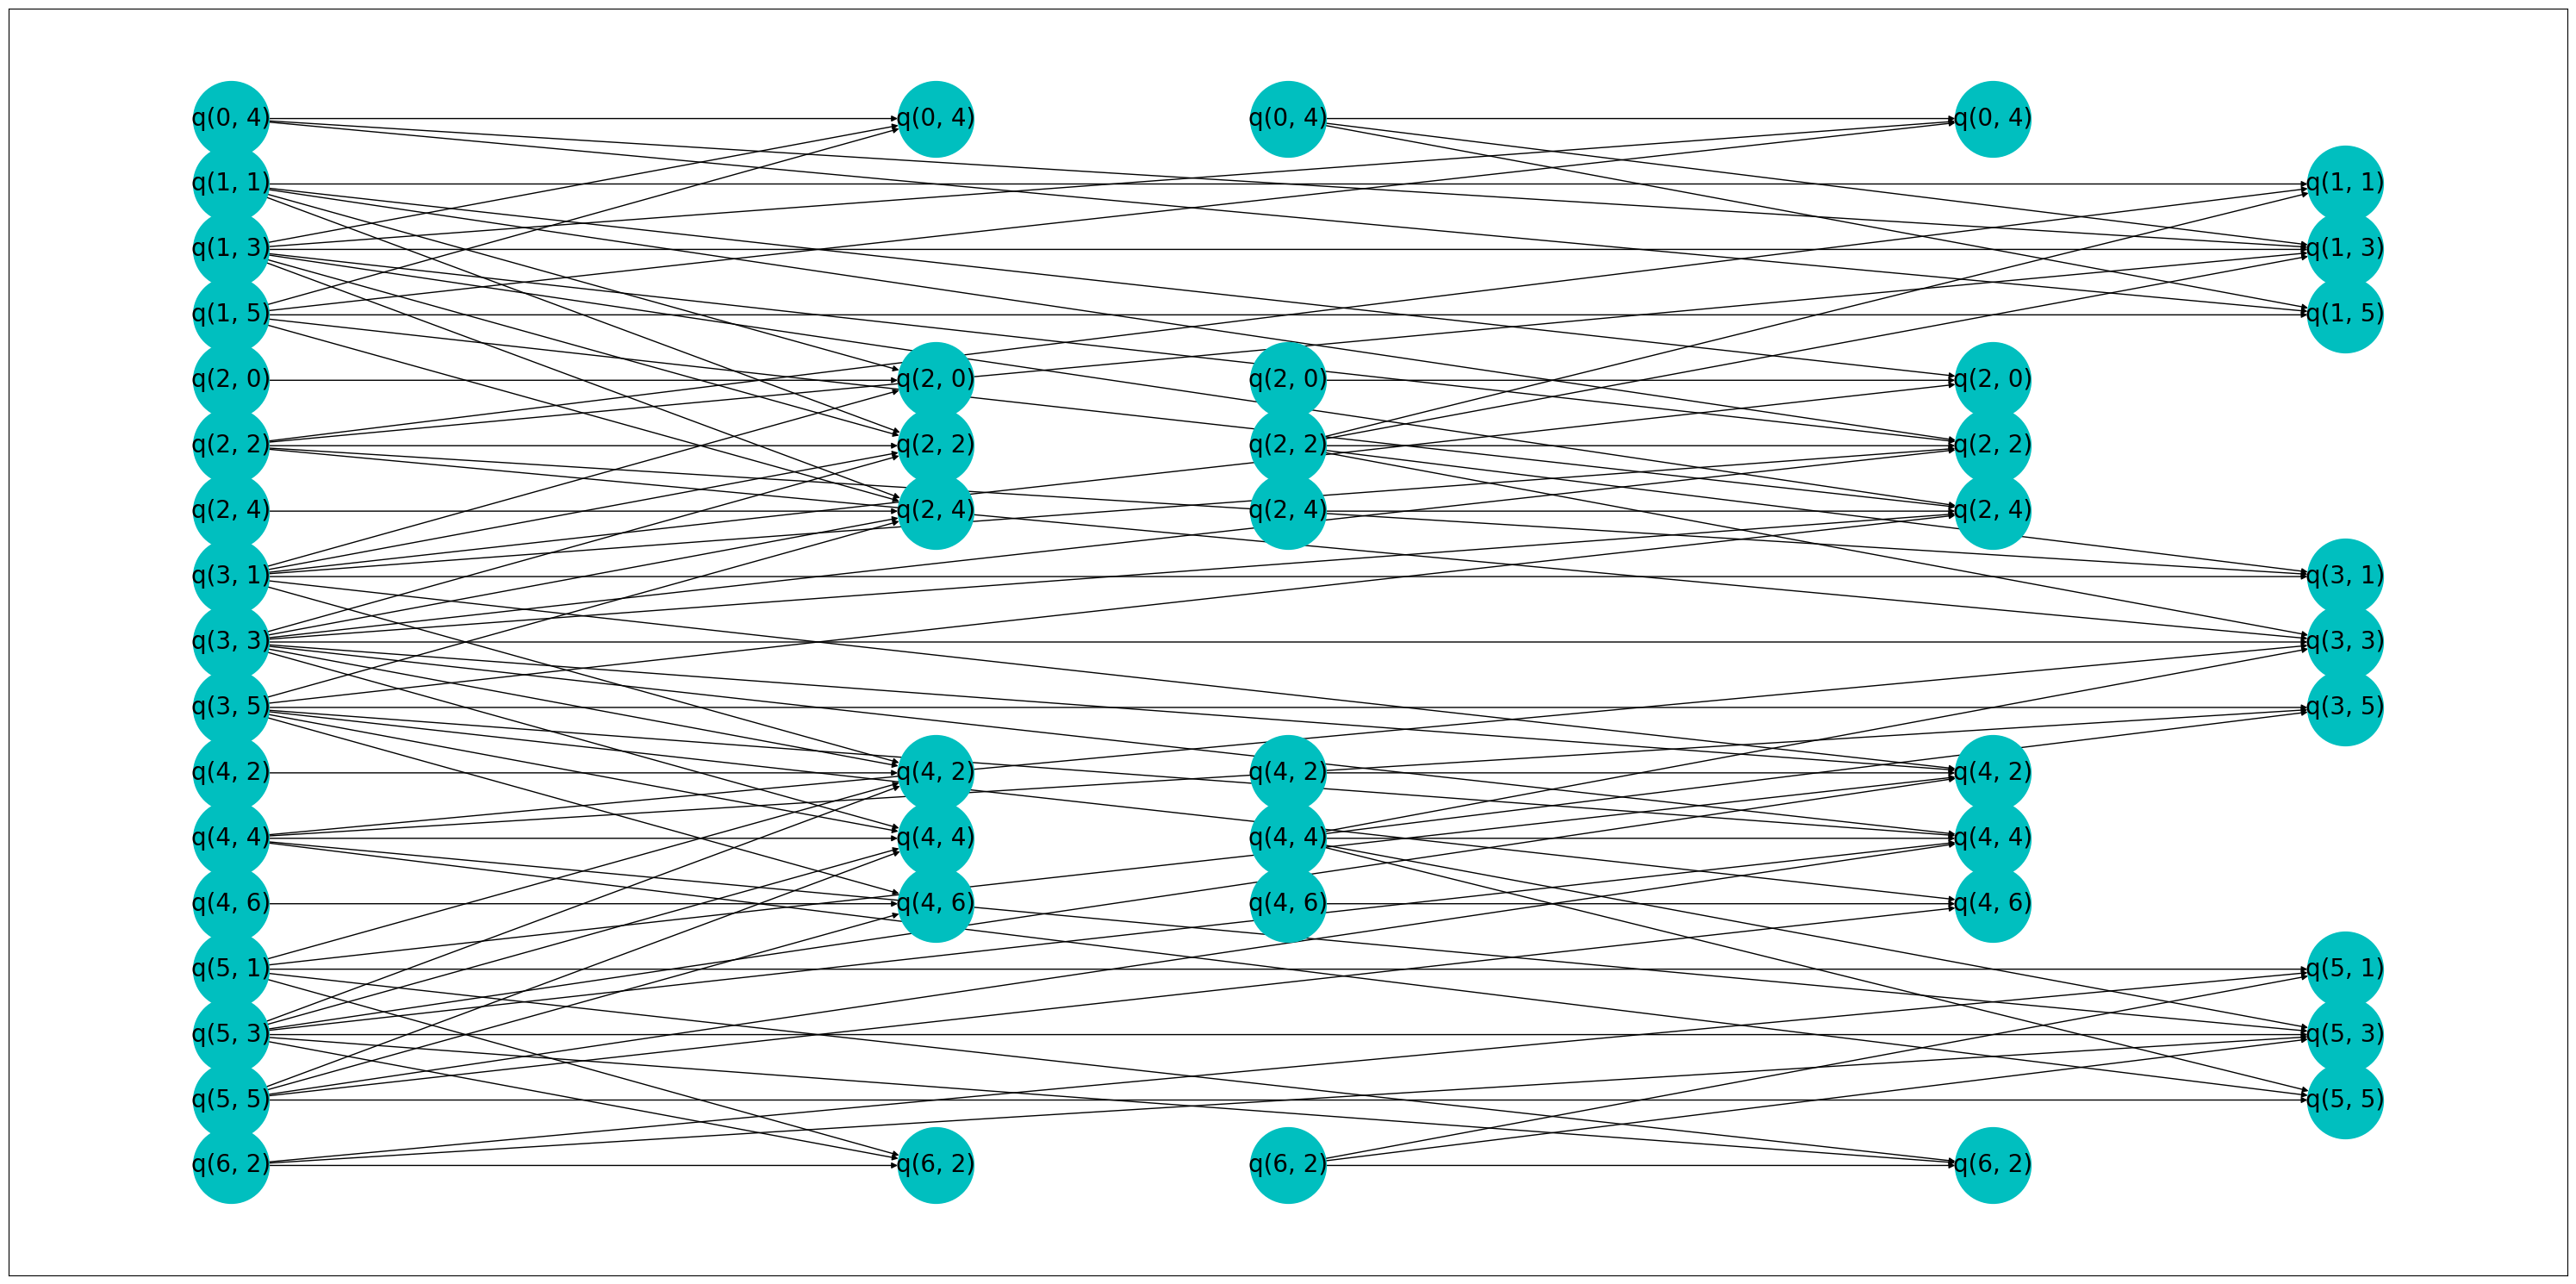

In [24]:
import networkx as nx
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(30, 15))
ax.invert_yaxis()

G = imap._map
qmap = tableau._qubit_map
nx.draw_networkx(
    G,
    pos={loc: (loc.time_coordinate, loc.space_coordinate) for loc in G.nodes},
    labels={loc: f"{qmap[loc.space_coordinate]}" for loc in G.nodes},
    font_size=20,
    node_color="c",
    node_size=4000,
    ax=ax,
)
fig.tight_layout()

In [ ]:
from tqec.circuit.clifford.interaction_map import find_detectors


find_detectors(imap)

Found detector for CollapsingOperationLocation(2, 4, Z): [CollapsingOperationLocation(2, 4, Z)]
No detector found for measurement CollapsingOperationLocation(2, 5, Z)
No detector found for measurement CollapsingOperationLocation(2, 0, Z)
No detector found for measurement CollapsingOperationLocation(2, 11, Z)
No detector found for measurement CollapsingOperationLocation(2, 16, Z)
Found detector for CollapsingOperationLocation(2, 12, Z): [CollapsingOperationLocation(2, 6, Z), CollapsingOperationLocation(2, 12, Z)]
Found detector for CollapsingOperationLocation(2, 10, Z): [CollapsingOperationLocation(2, 10, Z)]
Found detector for CollapsingOperationLocation(2, 6, Z): [CollapsingOperationLocation(2, 6, Z), CollapsingOperationLocation(2, 10, Z), CollapsingOperationLocation(2, 12, Z)]
Found detector for CollapsingOperationLocation(5, 10, Z): [CollapsingOperationLocation(5, 10, Z)]
Found detector for CollapsingOperationLocation(5, 5, Z): [CollapsingOperationLocation(2, 0, Z), CollapsingOperat